In [13]:
import csv
import random
import os

# Set seed for reproducibility
random.seed(42)

# Create directory structure if it doesn't exist
os.makedirs('data/raw', exist_ok=True)

# Define crop preferences (realistic agronomic relationships)
crop_preferences = {
    'Paddy': {'soil_type': ['Clay', 'Loam', 'Silty'], 'moisture_range': (30, 40), 'ph_range': (5.5, 7.0), 'N_range': (60, 100),
               'texture': ['Fine', 'Medium'], 'drainage': ['Poor', 'Moderate']},
    'Maize': {'soil_type': ['Loam', 'Sandy', 'Silty'], 'moisture_range': (20, 35), 'ph_range': (5.5, 7.5), 'N_range': (50, 90),
              'texture': ['Medium', 'Coarse'], 'drainage': ['Moderate', 'Good']},
    'Tur Dal': {'soil_type': ['Loam', 'Clay', 'Chalky'], 'moisture_range': (15, 30), 'ph_range': (6.0, 8.0), 'N_range': (20, 50),
                'texture': ['Medium', 'Fine'], 'drainage': ['Moderate', 'Good']},
    'Green Gram': {'soil_type': ['Sandy', 'Loam', 'Silty'], 'moisture_range': (15, 28), 'ph_range': (6.5, 7.5), 'N_range': (20, 45),
                   'texture': ['Medium', 'Coarse'], 'drainage': ['Good', 'Moderate']},
    'Tomato': {'soil_type': ['Loam', 'Sandy', 'Silty'], 'moisture_range': (25, 35), 'ph_range': (6.0, 7.0), 'N_range': (60, 95),
               'texture': ['Medium', 'Coarse'], 'drainage': ['Good']},
    'Onion': {'soil_type': ['Loam', 'Sandy', 'Silty'], 'moisture_range': (20, 32), 'ph_range': (6.0, 7.5), 'N_range': (50, 85),
              'texture': ['Medium', 'Fine'], 'drainage': ['Good', 'Moderate']},
    'Sugarcane': {'soil_type': ['Clay', 'Loam', 'Silty'], 'moisture_range': (30, 40), 'ph_range': (6.0, 7.5), 'N_range': (70, 100),
                  'texture': ['Fine', 'Medium'], 'drainage': ['Moderate', 'Good']},
    'Banana': {'soil_type': ['Loam', 'Clay', 'Silty'], 'moisture_range': (28, 38), 'ph_range': (6.5, 7.5), 'N_range': (65, 95),
               'texture': ['Fine', 'Medium'], 'drainage': ['Good', 'Moderate']},
    'Coconut': {'soil_type': ['Sandy', 'Loam', 'Silty'], 'moisture_range': (25, 35), 'ph_range': (5.5, 7.5), 'N_range': (40, 70),
                'texture': ['Coarse', 'Medium'], 'drainage': ['Good']},
    'Groundnut': {'soil_type': ['Sandy', 'Loam', 'Silty'], 'moisture_range': (18, 30), 'ph_range': (6.0, 7.5), 'N_range': (20, 50),
                  'texture': ['Coarse', 'Medium'], 'drainage': ['Good', 'Moderate']}
}

# Initialize
rows = []
crops = list(crop_preferences.keys())
previous_crops = [
    'Paddy', 'Maize', 'Tur Dal', 'Green Gram',
    'Tomato', 'Onion', 'Sugarcane', 'Banana', 'Coconut', 'Groundnut'
]


# Generate 40 examples per crop (total 400 rows)
for crop in crops:
    for _ in range(100):
        prefs = crop_preferences[crop]
        soil_type = random.choice(prefs['soil_type'])
        moisture = round(random.uniform(*prefs['moisture_range']), 1)
        ph = round(random.uniform(*prefs['ph_range']), 1)
        N = random.randint(*prefs['N_range'])
        texture = random.choice(prefs['texture'])
        drainage = random.choice(prefs['drainage'])

        P = random.randint(10, 60)
        K = random.randint(10, 80)
        organic_carbon = round(random.uniform(0.5, 2.5), 2)

        # Correlated soil health score
        base_health = 50 + (organic_carbon - 0.5) * 15
        npk_balance = min(N/100, P/60, K/80) * 20
        soil_health_index = int(min(100, base_health + npk_balance + random.uniform(-5, 5)))

        previous_crop = random.choice(previous_crops)
        acres = round(random.uniform(0.5, 10), 1)

        rows.append({
            'soil_type': soil_type,
            'soil_moisture': moisture,
            'soil_ph': ph,
            'N': N,
            'P': P,
            'K': K,
            'organic_carbon': organic_carbon,
            'texture': texture,
            'drainage': drainage,
            'soil_health_index': soil_health_index,
            'previous_crop': previous_crop,
            'acres': acres,
            'recommended_crop': crop
        })

# Shuffle for randomness
random.shuffle(rows)

# Save CSV
output_path = 'data/raw/crop_recommendation_dataset.csv'
with open(output_path, 'w', newline='') as f:
    fieldnames = ['soil_type', 'soil_moisture', 'soil_ph', 'N', 'P', 'K',
                  'organic_carbon', 'texture', 'drainage', 'soil_health_index',
                  'previous_crop', 'acres', 'recommended_crop']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

# Print confirmation
print(f"✅ Generated dataset with {len(rows)} rows")
print(f"📁 Saved to: {output_path}")
print("\n🌾 Crop distribution:")
for crop in crops:
    count = sum(1 for row in rows if row['recommended_crop'] == crop)
    print(f"{crop}: {count}")


✅ Generated dataset with 1000 rows
📁 Saved to: data/raw/crop_recommendation_dataset.csv

🌾 Crop distribution:
Paddy: 100
Maize: 100
Tur Dal: 100
Green Gram: 100
Tomato: 100
Onion: 100
Sugarcane: 100
Banana: 100
Coconut: 100
Groundnut: 100


In [3]:
import os
print(os.getcwd())


c:\Users\varsa\Agropulse\notebooks


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("data/raw/crop_recommendation_dataset.csv")

# Separate features and target
X = df.drop("recommended_crop", axis=1)
y = df["recommended_crop"]

# Identify categorical columns
categorical_cols = ["soil_type", "texture", "drainage", "previous_crop"]

# Encode categorical columns
encoder = LabelEncoder()
for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col])

# Encode target labels
y = LabelEncoder().fit_transform(y)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


✅ Preprocessing complete!
Train shape: (320, 12)
Test shape: (80, 12)


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree

# Train the Decision Tree model
model = DecisionTreeClassifier(random_state=42, max_depth=6)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
acc = accuracy_score(y_test, y_pred)
print(f"✅ Model trained successfully!")
print(f"Accuracy: {acc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


✅ Model trained successfully!
Accuracy: 0.55

Classification Report:
              precision    recall  f1-score   support

           0       0.44      1.00      0.62         8
           1       0.38      0.38      0.38         8
           2       0.80      0.44      0.57         9
           3       0.43      0.86      0.57         7
           4       0.30      0.50      0.38         6
           5       0.60      0.33      0.43         9
           6       0.57      0.57      0.57         7
           7       0.00      0.00      0.00         9
           8       1.00      0.20      0.33         5
           9       1.00      1.00      1.00        12

    accuracy                           0.55        80
   macro avg       0.55      0.53      0.48        80
weighted avg       0.56      0.55      0.51        80



c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


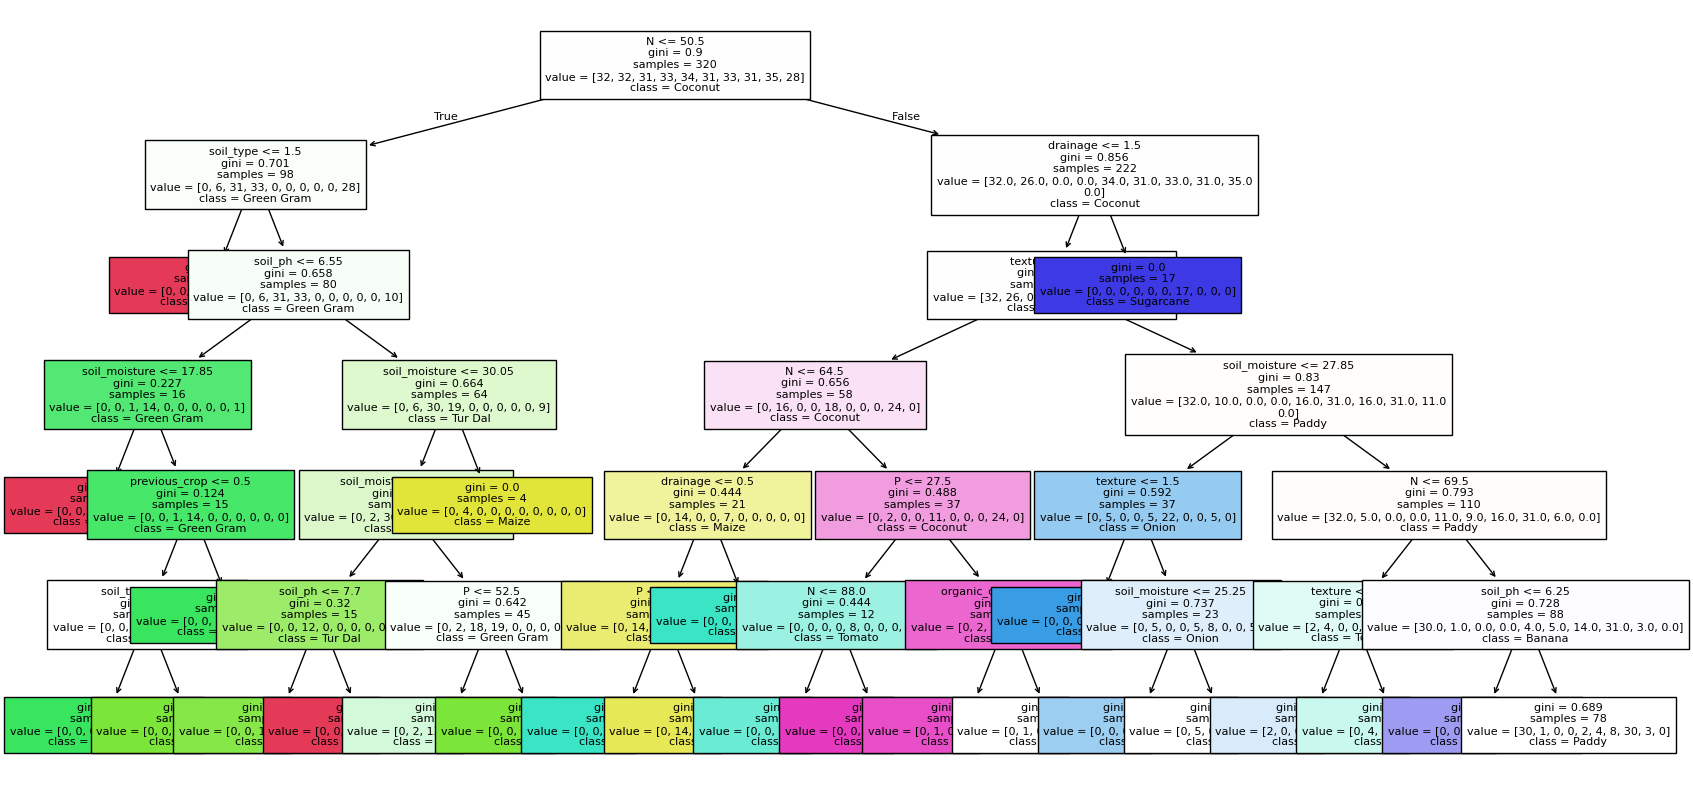

In [7]:
plt.figure(figsize=(20, 10))
tree.plot_tree(
    model, 
    feature_names=X_train.columns, 
    class_names=['Paddy', 'Maize', 'Tur Dal', 'Green Gram', 'Tomato', 'Onion', 'Sugarcane', 'Banana', 'Coconut', 'Groundnut'], 
    filled=True, 
    fontsize=8
)
plt.show()


In [8]:
# Example input (one farmer's soil data)
sample_input = pd.DataFrame([{
    'soil_type': 'Loam',
    'soil_moisture': 30.5,
    'soil_ph': 6.5,
    'N': 80,
    'P': 40,
    'K': 60,
    'organic_carbon': 1.5,
    'texture': 'Medium',
    'drainage': 'Moderate',
    'soil_health_index': 75,
    'previous_crop': 'Rice',
    'acres': 5.0
}])

# Encode the same way as training data
for col in ['soil_type', 'texture', 'drainage', 'previous_crop']:
    sample_input[col] = encoder.fit_transform(sample_input[col])

# Predict
prediction = model.predict(sample_input)[0]
print("🌾 Recommended Crop:", prediction)


🌾 Recommended Crop: 8


In [9]:
from sklearn.preprocessing import LabelEncoder

# Create a separate encoder for the target during preprocessing
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['recommended_crop'])

# After prediction
pred_label = model.predict(sample_input)[0]
predicted_crop = target_encoder.inverse_transform([pred_label])[0]
print("🌾 Recommended Crop:", predicted_crop)


🌾 Recommended Crop: Tomato


✅ Dataset loaded successfully!
  soil_type  soil_moisture  soil_ph   N   P   K  organic_carbon texture  \
0      Clay           30.3      7.0  97  39  79            2.37  Medium   
1     Silty           31.9      7.0  51  36  66            1.26  Medium   
2     Silty           30.0      6.8  90  29  74            1.60    Fine   
3     Silty           22.1      6.1  31  32  17            1.82  Medium   
4      Clay           32.4      7.4  93  59  34            0.71  Medium   

   drainage  soil_health_index previous_crop  acres recommended_crop  
0      Good                 91          Rice    9.7        Sugarcane  
1      Good                 72         Maize    7.2            Onion  
2  Moderate                 78         Wheat    7.0           Banana  
3  Moderate                 71     Sugarcane    3.5        Groundnut  
4      Good                 58     Groundnut    6.4           Banana  
✅ Preprocessing complete! Train shape: (480, 12), Test shape: (120, 12)

✅ Model trained suc

✅ Dataset loaded successfully!
  soil_type  soil_moisture  soil_ph   N   P   K  organic_carbon texture  \
0      Loam           23.8      7.3  26  47  20            1.05  Medium   
1      Loam           15.7      6.7  40  25  20            1.42  Coarse   
2      Clay           33.4      6.6  94  13  60            2.02    Fine   
3      Clay           20.5      7.8  25  24  51            1.00  Medium   
4      Loam           33.8      5.8  80  27  63            1.00  Medium   

   drainage  soil_health_index previous_crop  acres recommended_crop  
0      Good                 64         Onion    9.6        Groundnut  
1  Moderate                 71        Banana    1.3       Green Gram  
2      Good                 78       Tur Dal    9.1        Sugarcane  
3      Good                 66         Onion    3.1          Tur Dal  
4  Moderate                 62         Paddy    7.6            Paddy  
✅ Preprocessing complete! Train shape: (800, 12), Test shape: (200, 12)

✅ Model trained suc

c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


✅ Dataset loaded successfully!
  soil_type  soil_moisture  soil_ph   N   P   K  organic_carbon texture  \
0      Loam           23.8      7.3  26  47  20            1.05  Medium   
1      Loam           15.7      6.7  40  25  20            1.42  Coarse   
2      Clay           33.4      6.6  94  13  60            2.02    Fine   
3      Clay           20.5      7.8  25  24  51            1.00  Medium   
4      Loam           33.8      5.8  80  27  63            1.00  Medium   

   drainage  soil_health_index previous_crop  acres recommended_crop  
0      Good                 64         Onion    9.6        Groundnut  
1  Moderate                 71        Banana    1.3       Green Gram  
2      Good                 78       Tur Dal    9.1        Sugarcane  
3      Good                 66         Onion    3.1          Tur Dal  
4  Moderate                 62         Paddy    7.6            Paddy  
✅ Preprocessing complete! Train shape: (800, 12), Test shape: (200, 12)

✅ Model trained suc

c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
# ============================================
# 🌾 Crop Recommendation using Random Forest + Suitability Scoring
# ============================================


import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import numpy as np


# ============================================
# 1️⃣ Load Dataset
# ============================================
data_path = "data/raw/crop_recommendation_dataset.csv"
df = pd.read_csv(data_path)
print("✅ Dataset loaded successfully!")
print(df.head())


# ============================================
# 2️⃣ Encode Categorical Columns
# ============================================
label_encoders = {}
categorical_cols = ['soil_type', 'texture', 'drainage', 'previous_crop', 'recommended_crop']


for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


# ============================================
# 3️⃣ Split Data
# ============================================
X = df.drop('recommended_crop', axis=1)
y = df['recommended_crop']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"✅ Preprocessing complete! Train shape: {X_train.shape}, Test shape: {X_test.shape}")


# ============================================
# 4️⃣ Train Model
# ============================================
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    min_samples_split=4
)
model.fit(X_train, y_train)


# ============================================
# 5️⃣ Evaluate Model
# ============================================
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model trained successfully! Accuracy: {acc:.2f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


# ============================================
# 6️⃣ Save Model (Fixed for Agropulse/app/models)
# ============================================
BASE_DIR = os.path.dirname(os.getcwd())  # from notebooks → agropulse
MODEL_DIR = os.path.join(BASE_DIR, "app", "models")
os.makedirs(MODEL_DIR, exist_ok=True)


model_path = os.path.join(MODEL_DIR, "random_forest_crop_model.pkl")
encoder_path = os.path.join(MODEL_DIR, "crop_recommendation.pkl")


joblib.dump(model, model_path)
joblib.dump(label_encoders, encoder_path)


print(f"✅ Model saved at: {os.path.abspath(model_path)}")
print(f"✅ Label encoders saved at: {os.path.abspath(encoder_path)}")


# ============================================
# 7️⃣ Safe Encoder Function
# ============================================
def safe_encode(encoder, value):
    value = value.strip().lower()
    if value in encoder.classes_:
        return encoder.transform([value])[0]
    else:
        print(f"⚠️ Unseen value '{value}' replaced with '{encoder.classes_[0]}'")
        return encoder.transform([encoder.classes_[0]])[0]


# ============================================
# 8️⃣ Crop Rotation Rules (Smart Agro Logic)
# ============================================
rotation_rules = {
    'paddy': ['maize', 'groundnut', 'onion'],
    'maize': ['tur dal', 'green gram', 'tomato'],
    'groundnut': ['sugarcane', 'banana', 'coconut'],
    'sugarcane': ['paddy', 'tur dal'],
    'banana': ['onion', 'tomato', 'groundnut'],
    'onion': ['paddy', 'maize', 'banana'],
    'tomato': ['tur dal', 'groundnut', 'banana'],
    'tur dal': ['maize', 'onion', 'sugarcane'],
    'green gram': ['maize', 'banana', 'onion'],
    'coconut': ['groundnut', 'onion']
}


def recommend_crop_with_rotation(model, input_data, previous_crop):
    probs = model.predict_proba([input_data])[0]
    crop_labels = model.classes_
    ranked_crops = [crop for _, crop in sorted(zip(probs, crop_labels), reverse=True)]
    for crop in ranked_crops:
        decoded_crop = label_encoders['recommended_crop'].inverse_transform([crop])[0]
        if decoded_crop in rotation_rules.get(previous_crop.lower(), []):
            return decoded_crop
    return label_encoders['recommended_crop'].inverse_transform([ranked_crops[0]])[0]


# ============================================
# 9️⃣ Additional Agro Rules (Soil-Drainage Logic)
# ============================================
def apply_agro_rules(predicted_crop, soil_type, previous_crop, drainage):
    if previous_crop == "paddy" and soil_type in ["clay", "silty"]:
        if predicted_crop in ["tomato", "onion"]:
            return "maize"
    if soil_type == "clay" and drainage == "poor":
        if predicted_crop in ["tomato", "onion"]:
            return "groundnut"
    if previous_crop == "banana" and predicted_crop == "sugarcane":
        return "paddy"
    return predicted_crop


# ============================================
# 🔟 Crop Suitability Scoring Function
# ============================================
def get_crop_scores(model, encoders, input_data, top_k=3):
    """
    Returns top-k crops with suitability scores (0–1)
    """
    probs = model.predict_proba([input_data])[0]
    crop_labels = model.classes_
    crop_names = encoders['recommended_crop'].inverse_transform(crop_labels)
    crop_probs = dict(zip(crop_names, probs))
    top_crops = sorted(crop_probs.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return top_crops  # list of (crop, score)


# ============================================
# 🔟 Sample Test
# ============================================
sample = {
    'soil_type': 'Clay',
    'soil_moisture': 33.5,
    'soil_ph': 6.5,
    'N': 70,
    'P': 40,
    'K': 35,
    'organic_carbon': 1.8,
    'texture': 'Medium',
    'drainage': 'Moderate',
    'soil_health_index': 75,
    'previous_crop': 'Paddy',
    'acres': 3.2
}


encoded_sample = {}
for key, value in sample.items():
    if key in label_encoders:
        encoded_sample[key] = safe_encode(label_encoders[key], str(value))
    else:
        encoded_sample[key] = value


sample_df = pd.DataFrame([encoded_sample])


# Predict with rotation logic
final_crop = recommend_crop_with_rotation(model, list(sample_df.iloc[0]), sample['previous_crop'])


# Apply additional rules
final_crop = apply_agro_rules(
    predicted_crop=final_crop,
    soil_type=sample['soil_type'].lower(),
    previous_crop=sample['previous_crop'].lower(),
    drainage=sample['drainage'].lower()
)


# Get Top-3 Crops with Scores
top3_crops = get_crop_scores(model, label_encoders, list(sample_df.iloc[0]), top_k=3)


print(f"\n🌾 Recommended Crop (ML + Logic): {final_crop}")
print("\n📊 Top-3 Crops with Suitability Scores:")
for crop, score in top3_crops:
    print(f"   {crop}: {score:.3f}")


✅ Dataset loaded successfully!
  soil_type  soil_moisture  soil_ph   N   P   K  organic_carbon texture  \
0      Loam           23.8      7.3  26  47  20            1.05  Medium   
1      Loam           15.7      6.7  40  25  20            1.42  Coarse   
2      Clay           33.4      6.6  94  13  60            2.02    Fine   
3      Clay           20.5      7.8  25  24  51            1.00  Medium   
4      Loam           33.8      5.8  80  27  63            1.00  Medium   

   drainage  soil_health_index previous_crop  acres recommended_crop  
0      Good                 64         Onion    9.6        Groundnut  
1  Moderate                 71        Banana    1.3       Green Gram  
2      Good                 78       Tur Dal    9.1        Sugarcane  
3      Good                 66         Onion    3.1          Tur Dal  
4  Moderate                 62         Paddy    7.6            Paddy  
✅ Preprocessing complete! Train shape: (800, 12), Test shape: (200, 12)

✅ Model trained suc

c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\varsa\anaconda3\envs\py310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
import joblib

encoders = joblib.load(r"C:\Users\varsa\Agropulse\app\models\crop_label_encoders.pkl")
print(encoders.keys())


dict_keys(['season', 'label'])


In [2]:
import joblib

encoders = joblib.load(r"C:\Users\varsa\Agropulse\app\models\crop_label_encoders.pkl")
print(encoders)


{'season': LabelEncoder(), 'label': LabelEncoder()}
